# 07 - Final Dashboard

Build visual summary dashboard (plotly + mplsoccer).

Using game_id=2023090700, play_id=101, WR=44930, DB=46137
Saved rsi_play_final_fromdata.gif


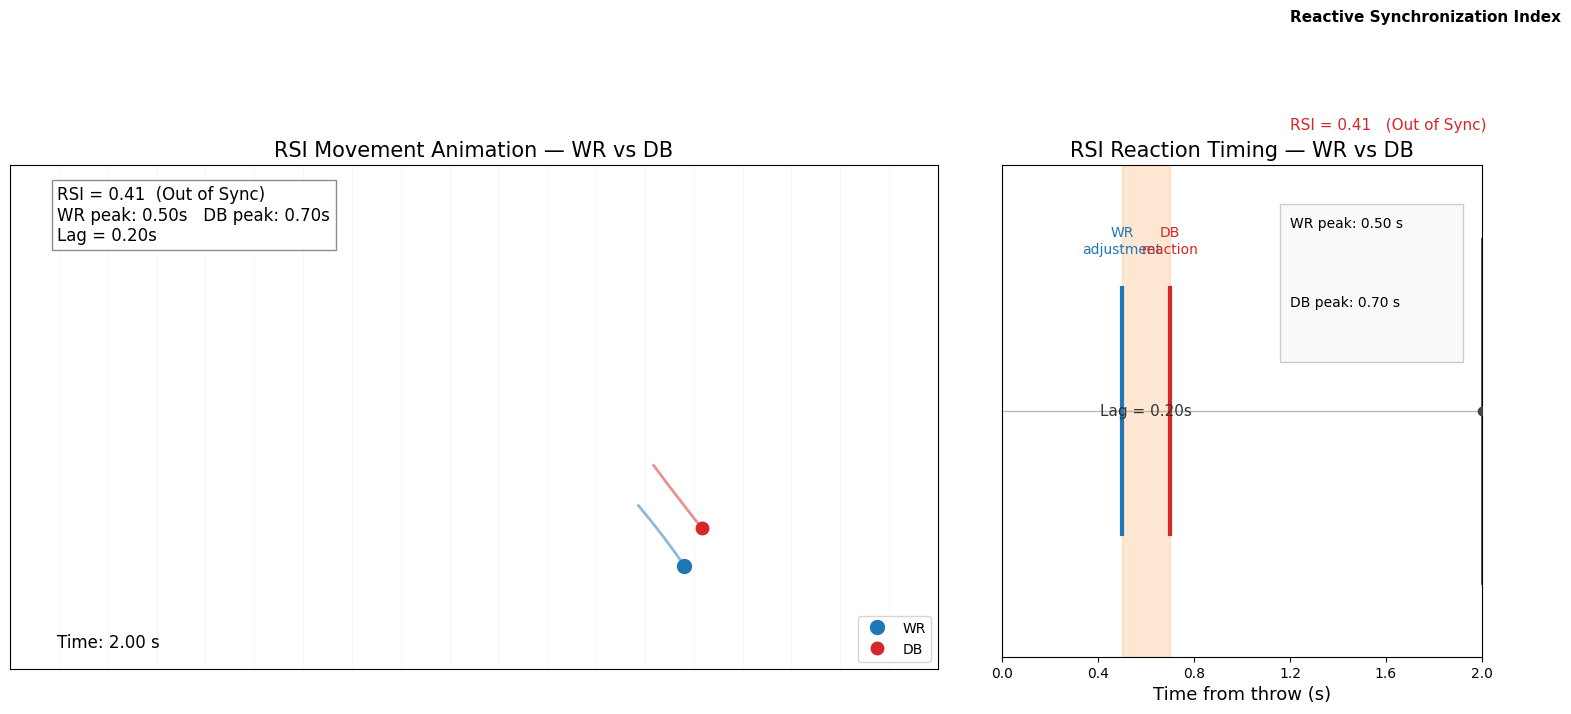

In [8]:
# rsi_visualization_from_data.py

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.patches import Rectangle

# =========================================================
# 1. Load RSI data and pick ONE play (WR–DB pair)
# =========================================================

PATH = "/content/final_rsi_enriched.parquet"
df = pd.read_parquet(PATH)

# Ensure sorted by time for each play
df = df.sort_values(["game_id", "play_id", "wr_nfl_id", "db_nfl_id", "time_from_throw"])

# ---- choose which play to visualize ----
# Option A: first unique combo
play_keys = (
    df[["game_id", "play_id", "wr_nfl_id", "db_nfl_id"]]
    .drop_duplicates()
    .reset_index(drop=True)
)

play_idx = 0  # <-- change this index to show a different play (0,1,2,...)

game_id_sel = int(play_keys.loc[play_idx, "game_id"])
play_id_sel = int(play_keys.loc[play_idx, "play_id"])
wr_id_sel   = int(play_keys.loc[play_idx, "wr_nfl_id"])
db_id_sel   = int(play_keys.loc[play_idx, "db_nfl_id"])

print(f"Using game_id={game_id_sel}, play_id={play_id_sel}, WR={wr_id_sel}, DB={db_id_sel}")

play = df[
    (df["game_id"] == game_id_sel)
    & (df["play_id"] == play_id_sel)
    & (df["wr_nfl_id"] == wr_id_sel)
    & (df["db_nfl_id"] == db_id_sel)
].copy()

# Safety: sort again by time
play = play.sort_values("time_from_throw")

# Extract time and positions
t = play["time_from_throw"].to_numpy()
x_wr = play["x_s_wr"].to_numpy()
y_wr = play["y_s_wr"].to_numpy()
x_db = play["x_s_db"].to_numpy()
y_db = play["y_s_db"].to_numpy()

# Single RSI value for this pair (same every row)
RSI = float(play["RSI"].iloc[0])

# -------------------------------------------------
# Find WR and DB peak adjustment times from d_dir_*
# -------------------------------------------------
# WR peak
d_wr = play["d_dir_wr"].to_numpy()
valid_wr = ~np.isnan(d_wr)
if valid_wr.sum() > 0:
    idx_wr_peak_local = np.argmax(np.abs(d_wr[valid_wr]))
    t_wr_peak = float(t[valid_wr][idx_wr_peak_local])
else:
    # fallback: middle of flight
    t_wr_peak = float(np.median(t))

# DB peak
d_db = play["d_dir_db"].to_numpy()
valid_db = ~np.isnan(d_db)
if valid_db.sum() > 0:
    idx_db_peak_local = np.argmax(np.abs(d_db[valid_db]))
    t_db_peak = float(t[valid_db][idx_db_peak_local])
else:
    t_db_peak = float(np.median(t))

lag = abs(t_wr_peak - t_db_peak)

# Indices nearest to peaks (for halo effect)
i_wr_peak = int(np.argmin(np.abs(t - t_wr_peak)))
i_db_peak = int(np.argmin(np.abs(t - t_db_peak)))

# Field extents (tight around this play)
margin_x = 5.0
margin_y = 5.0
min_x = min(x_wr.min(), x_db.min()) - margin_x
max_x = max(x_wr.max(), x_db.max()) + margin_x
min_y = min(y_wr.min(), y_db.min()) - margin_y
max_y = max(y_wr.max(), y_db.max()) + margin_y

# =========================================================
# 2. Figure & Axes Setup
# =========================================================

FIG_W, FIG_H = 16, 6
fig = plt.figure(figsize=(FIG_W, FIG_H), dpi=100)

# Left: field panel
ax_field = fig.add_axes([0.04, 0.08, 0.58, 0.84])

# Right: timeline panel
ax_timeline = fig.add_axes([0.66, 0.10, 0.30, 0.82])

# =========================================================
# 3. Left panel content (field + movement)
# =========================================================

ax_field.set_xlim(min_x, max_x)
ax_field.set_ylim(min_y, max_y)
ax_field.set_xticks([])
ax_field.set_yticks([])
ax_field.set_title("RSI Movement Animation — WR vs DB", fontsize=15)

# subtle yardlines every yard in x (using play-space, not full field)
for x_line in np.linspace(min_x, max_x, int(max_x - min_x) + 1):
    ax_field.axvline(x_line, color="#EEEEEE", lw=0.6, alpha=0.6, zorder=0)

# Artists for WR/DB markers and trails
wr_dot, = ax_field.plot([], [], "o", markersize=10, color="#1f77b4", zorder=5, label="WR")
db_dot, = ax_field.plot([], [], "o", markersize=9, color="#d62728", zorder=5, label="DB")
wr_trail, = ax_field.plot([], [], "-", lw=2, color="#1f77b4", alpha=0.5, zorder=4)
db_trail, = ax_field.plot([], [], "-", lw=2, color="#d62728", alpha=0.5, zorder=4)
wr_halo, = ax_field.plot([], [], "o", markersize=20, alpha=0.25, color="#1f77b4", zorder=3)
db_halo, = ax_field.plot([], [], "o", markersize=20, alpha=0.25, color="#d62728", zorder=3)

# RSI summary on the field
sync_label = (
    "High Sync" if RSI >= 0.75 else ("Moderate" if RSI >= 0.5 else "Out of Sync")
)
rsi_text = ax_field.text(
    min_x + 1,
    max_y - 1,
    f"RSI = {RSI:.2f}  ({sync_label})\n"
    f"WR peak: {t_wr_peak:.2f}s   DB peak: {t_db_peak:.2f}s\n"
    f"Lag = {lag:.2f}s",
    fontsize=12,
    ha="left",
    va="top",
    bbox=dict(facecolor="white", edgecolor="gray", alpha=0.9),
    zorder=10,
)

time_text = ax_field.text(
    min_x + 1,
    min_y + 1,
    "",
    fontsize=12,
    zorder=10,
)

ax_field.legend(loc="lower right", frameon=True, fontsize=10)

# =========================================================
# 4. Right panel content (timeline + lag band)
# =========================================================

ax_timeline.set_xlim(t.min(), t.max())
ax_timeline.set_ylim(0, 1)
ax_timeline.set_yticks([])
ax_timeline.set_xlabel("Time from throw (s)", fontsize=13)
ax_timeline.set_title("RSI Reaction Timing — WR vs DB", fontsize=15)

baseline_y = 0.5
baseline_line, = ax_timeline.plot(
    [t.min(), t.max()], [baseline_y, baseline_y], color="#BBBBBB", lw=1, zorder=1
)

# Peak lines
wr_peak_line, = ax_timeline.plot(
    [t_wr_peak, t_wr_peak], [0.25, 0.75], color="#1f77b4", lw=3, zorder=5
)
db_peak_line, = ax_timeline.plot(
    [t_db_peak, t_db_peak], [0.25, 0.75], color="#d62728", lw=3, zorder=5
)

# Peak labels
wr_peak_text = ax_timeline.text(
    t_wr_peak,
    0.82,
    "WR\nadjustment",
    color="#1f77b4",
    ha="center",
    fontsize=10,
    zorder=6,
)
db_peak_text = ax_timeline.text(
    t_db_peak,
    0.82,
    "DB\nreaction",
    color="#d62728",
    ha="center",
    fontsize=10,
    zorder=6,
)

# Shaded lag band
lag_min, lag_max = min(t_wr_peak, t_db_peak), max(t_wr_peak, t_db_peak)
if lag < 0.10:
    band_color = (44 / 255, 160 / 255, 44 / 255, 0.18)  # green
elif lag < 0.25:
    band_color = (255 / 255, 127 / 255, 14 / 255, 0.18)  # orange
else:
    band_color = (214 / 255, 39 / 255, 40 / 255, 0.18)   # red

lag_rect = Rectangle((lag_min, 0), lag_max - lag_min, 1.0, color=band_color, zorder=2)
ax_timeline.add_patch(lag_rect)

lag_label = ax_timeline.text(
    (lag_min + lag_max) / 2,
    baseline_y,
    f"Lag = {lag:.2f}s",
    fontsize=11,
    ha="center",
    va="center",
    color="#333333",
    zorder=7,
)

# Cursor line & dot (moves with animation)
cursor_line, = ax_timeline.plot(
    [t[0], t[0]], [0.15, 0.85], color="#444444", lw=2, zorder=9
)
cursor_dot, = ax_timeline.plot(
    [], [], "o", color="#444444", markersize=6, zorder=10
)

ax_timeline.set_xticks(np.linspace(t.min(), t.max(), min(6, len(t))))
ax_timeline.tick_params(axis="x", labelsize=10)

# RSI summary box on right panel
box_x, box_y, box_w, box_h = 0.58, 0.60, 0.38, 0.32
summary_box = Rectangle(
    (box_x, box_y),
    box_w,
    box_h,
    transform=ax_timeline.transAxes,
    facecolor="#F9F9F9",
    edgecolor="#CCCCCC",
    zorder=12,
)
ax_timeline.add_patch(summary_box)

summary_title = ax_timeline.text(
    box_x + 0.02,
    box_y + 0.70,
    "Reactive Synchronization Index",
    transform=ax_timeline.transAxes,
    fontsize=11,
    fontweight="bold",
    va="center",
    zorder=13,
)

rsi_color = "#2ca02c" if RSI >= 0.75 else ("#ff7f0e" if RSI >= 0.5 else "#d62728")
summary_val = ax_timeline.text(
    box_x + 0.02,
    box_y + 0.48,
    f"RSI = {RSI:.2f}   ({sync_label})",
    transform=ax_timeline.transAxes,
    fontsize=11,
    color=rsi_color,
    va="center",
    zorder=13,
)

summary_wr = ax_timeline.text(
    box_x + 0.02,
    box_y + 0.28,
    f"WR peak: {t_wr_peak:.2f} s",
    transform=ax_timeline.transAxes,
    fontsize=10,
    va="center",
    zorder=13,
)

summary_db = ax_timeline.text(
    box_x + 0.02,
    box_y + 0.12,
    f"DB peak: {t_db_peak:.2f} s",
    transform=ax_timeline.transAxes,
    fontsize=10,
    va="center",
    zorder=13,
)

# =========================================================
# 5. Animation update function
# =========================================================

def update(frame):
    # ---- left panel: WR/DB movement ----
    wr_dot.set_data([x_wr[frame]], [y_wr[frame]])
    db_dot.set_data([x_db[frame]], [y_db[frame]])

    start = max(0, frame - 4)
    wr_trail.set_data(x_wr[start:frame + 1], y_wr[start:frame + 1])
    db_trail.set_data(x_db[start:frame + 1], y_db[start:frame + 1])

    # halo only at peak frames
    if frame == i_wr_peak:
        wr_halo.set_data([x_wr[frame]], [y_wr[frame]])
    else:
        wr_halo.set_data([], [])
    if frame == i_db_peak:
        db_halo.set_data([x_db[frame]], [y_db[frame]])
    else:
        db_halo.set_data([], [])

    time_text.set_text(f"Time: {t[frame]:.2f} s")

    # ---- right panel: move cursor ----
    cursor_line.set_data([t[frame], t[frame]], [0.15, 0.85])
    cursor_dot.set_data([t[frame]], [baseline_y])

    return [
        wr_dot,
        db_dot,
        wr_trail,
        db_trail,
        wr_halo,
        db_halo,
        time_text,
        cursor_line,
        cursor_dot,
        wr_peak_line,
        db_peak_line,
        lag_rect,
        lag_label,
        summary_box,
        summary_title,
        summary_val,
        summary_wr,
        summary_db,
    ]


# =========================================================
# 6. Run animation & save
# =========================================================

anim = FuncAnimation(fig, update, frames=len(t), interval=120, blit=True)
anim.save("rsi_play_final_fromdata.gif", writer=PillowWriter(fps=10))
print("Saved rsi_play_final_fromdata.gif")


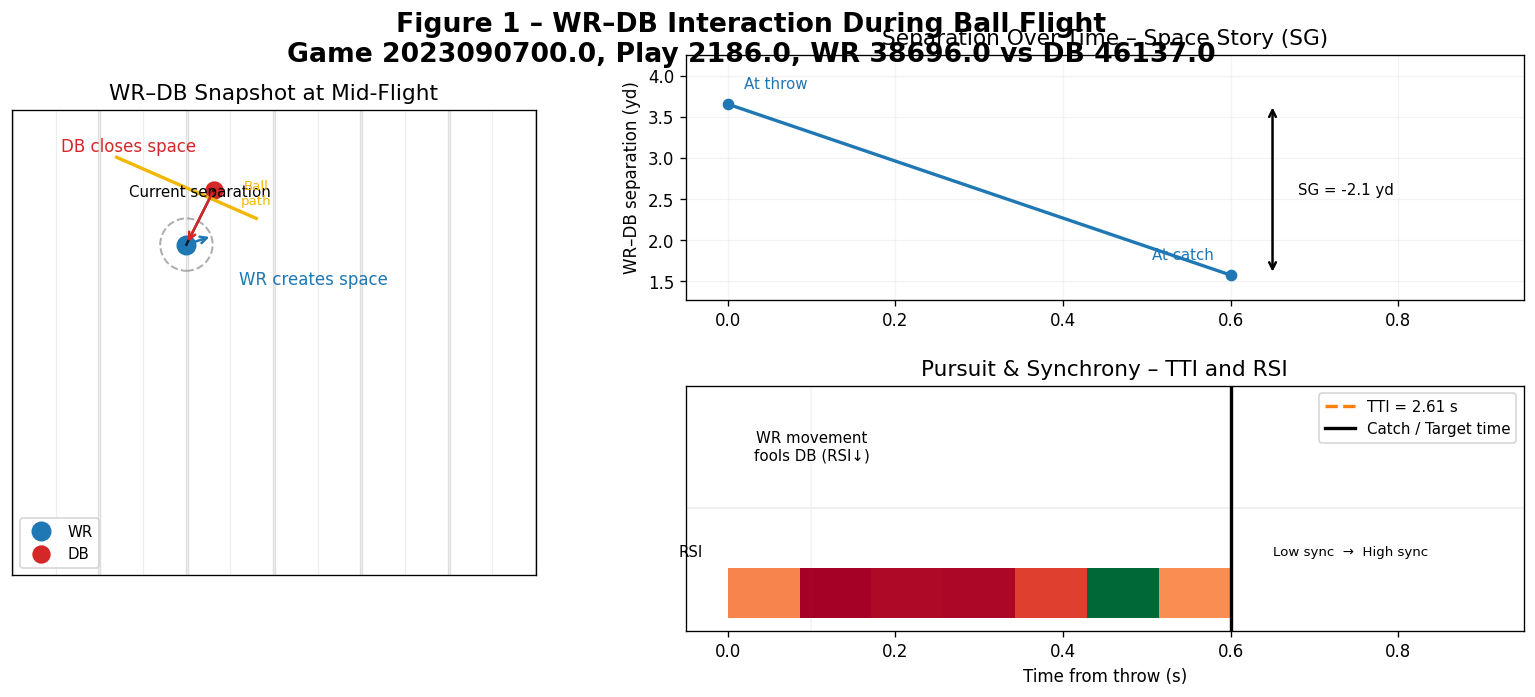

Saved figure1_interaction_map_game2023090700.0_play2186.0.png


In [25]:
"""
Figure 1 – WR–DB Interaction During Ball Flight
Using real data, random complete WR–DB pair each run.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from matplotlib import gridspec

# ---------------------------------------------------
# 1. Load data
# ---------------------------------------------------
path_rsi   = "/content/final_rsi_enriched.parquet"
path_cci   = "/content/metric_cci.parquet"                  # not used directly here but loaded if you want later
path_tti   = "/content/per_play_defender_movement.parquet"
path_sg    = "/content/aggregated_week01.parquet"

df_rsi  = pd.read_parquet(path_rsi)
df_cci  = pd.read_parquet(path_cci)
df_tti  = pd.read_parquet(path_tti)
df_sg   = pd.read_parquet(path_sg)

# ---------------------------------------------------
# 2. Prepare keys and join so we only pick "complete" plays
#    (RSI + SG + TTI all available for same WR–DB pair)
# ---------------------------------------------------

# RSI play-level keys
rsi_pairs = (
    df_rsi[["game_id", "play_id", "wr_nfl_id", "db_nfl_id", "RSI", "S_dir_avg", "S_time", "S_mag"]]
    .drop_duplicates()
)

# TTI: align column names with RSI pairs (wr_nfl_id / db_nfl_id)
df_tti_renamed = df_tti.rename(columns={"wr_id": "wr_nfl_id", "defender_id": "db_nfl_id"})
tti_pairs = df_tti_renamed[
    ["game_id", "play_id", "wr_nfl_id", "db_nfl_id", "tti", "avg_v_close", "early_v_close", "distance_throw"]
]

# SG: align WR id column name
df_sg_renamed = df_sg.rename(columns={"nfl_id": "wr_nfl_id"})
sg_pairs = df_sg_renamed[
    ["game_id", "play_id", "wr_nfl_id", "sep_at_throw", "sep_at_catch_end", "sep_gain", "time_to_land_loc"]
]

# Merge RSI + TTI
merged = pd.merge(
    rsi_pairs,
    tti_pairs,
    on=["game_id", "play_id", "wr_nfl_id", "db_nfl_id"],
    how="inner"
)

# Merge with SG
merged = pd.merge(
    merged,
    sg_pairs,
    on=["game_id", "play_id", "wr_nfl_id"],
    how="inner"
)

# Keep only rows with all core metrics non-null
merged = merged[
    merged["tti"].notna()
    & merged["sep_at_throw"].notna()
    & merged["sep_at_catch_end"].notna()
    & merged["RSI"].notna()
]

if merged.empty:
    raise ValueError("No complete plays found (RSI + TTI + SG). Check your data/filtering.")

# ---------------------------------------------------
# 3. Pick a random complete play
# ---------------------------------------------------
play_row = merged.sample(1, random_state=None).iloc[0]

g_id  = play_row["game_id"]
p_id  = play_row["play_id"]
wr_id = play_row["wr_nfl_id"]
db_id = play_row["db_nfl_id"]

RSI_play   = float(play_row["RSI"])
S_dir_avg  = float(play_row["S_dir_avg"])
S_time     = float(play_row["S_time"])
S_mag      = float(play_row["S_mag"])

sep_at_throw = float(play_row["sep_at_throw"])
sep_at_catch = float(play_row["sep_at_catch_end"])
sg           = float(play_row["sep_gain"])
t_catch_est  = float(play_row["time_to_land_loc"])

tti_val      = float(play_row["tti"])

# ---------------------------------------------------
# 4. Extract frame-level series for this play/pair from RSI data
# ---------------------------------------------------
play_frames = df_rsi[
    (df_rsi["game_id"] == g_id)
    & (df_rsi["play_id"] == p_id)
    & (df_rsi["wr_nfl_id"] == wr_id)
    & (df_rsi["db_nfl_id"] == db_id)
    & (df_rsi["is_in_flight"] == True)
].copy()

if play_frames.empty:
    raise ValueError("Selected play has no in-flight frames; try re-running to pick another play.")

# Sort by time
play_frames = play_frames.sort_values("time_from_throw")

t = play_frames["time_from_throw"].to_numpy()
t_catch = t.max()  # use actual last in-flight frame as catch/target time

# WR/DB positions for left panel: take mid-flight frame
mid_idx = len(play_frames) // 2
mid_row = play_frames.iloc[mid_idx]
wr_x, wr_y = float(mid_row["x_s_wr"]), float(mid_row["y_s_wr"])
db_x, db_y = float(mid_row["x_s_db"]), float(mid_row["y_s_db"])

# Instantaneous synchrony: use S_dir_t (if available), else fallback to flat RSI
inst_sync = play_frames["S_dir_t"].to_numpy()
if np.all(np.isnan(inst_sync)):
    inst_sync = np.full_like(t, RSI_play)
else:
    # fill NaNs with mean of non-NaNs
    mean_sync = np.nanmean(inst_sync)
    inst_sync = np.where(np.isnan(inst_sync), mean_sync, inst_sync)

# Normalize for color bar (0–1)
inst_norm = (inst_sync - np.nanmin(inst_sync)) / (np.nanmax(inst_sync) - np.nanmin(inst_sync) + 1e-6)

# Estimate WR/DB peak adjustment times from |d_dir|
d_wr = play_frames["d_dir_wr"].to_numpy()
d_db = play_frames["d_dir_db"].to_numpy()

# If everything is NaN, just pick first/last frame; otherwise argmax
if np.all(np.isnan(d_wr)):
    t_wr_peak = t[0]
else:
    idx_wr_peak = int(np.nanargmax(np.abs(d_wr)))
    t_wr_peak = float(t[idx_wr_peak])

if np.all(np.isnan(d_db)):
    t_db_peak = t[-1]
else:
    idx_db_peak = int(np.nanargmax(np.abs(d_db)))
    t_db_peak = float(t[idx_db_peak])

lag = abs(t_wr_peak - t_db_peak)

# For SG curve: interpolate between sep_at_throw and sep_at_catch over t
sep = np.linspace(sep_at_throw, sep_at_catch, len(t))

# ---------------------------------------------------
# 5. Build the figure (same layout you liked)
# ---------------------------------------------------
fig = plt.figure(figsize=(14, 6), dpi=120)
gs = gridspec.GridSpec(
    2, 2,
    width_ratios=[1.0, 1.6],
    height_ratios=[1.0, 1.0]
)

plt.subplots_adjust(
    left=0.06, right=0.96,
    top=0.90, bottom=0.10,
    wspace=0.22, hspace=0.35
)

ax_field = fig.add_subplot(gs[:, 0])
ax_sep   = fig.add_subplot(gs[0, 1])
ax_tti   = fig.add_subplot(gs[1, 1])

fig.suptitle(
    f"Figure 1 – WR–DB Interaction During Ball Flight\n"
    f"Game {g_id}, Play {p_id}, WR {wr_id} vs DB {db_id}",
    fontsize=16, fontweight="bold", y=0.96
)

# ---------------------------------------------------
# 5.1 Left: Field snapshot (using real mid-flight positions)
# ---------------------------------------------------
ax_field.set_title("WR–DB Snapshot at Mid-Flight", fontsize=13)

ax_field.set_xlim(0, 60)
ax_field.set_ylim(0, 53.3)
ax_field.set_aspect("equal")
ax_field.set_xticks([])
ax_field.set_yticks([])

# yardlines
for x in range(0, 61, 10):
    ax_field.axvline(x, color="#dddddd", lw=2, zorder=0)
for x in range(0, 61, 5):
    ax_field.axvline(x, color="#eeeeee", lw=0.7, zorder=0)

# WR / DB
ax_field.plot(wr_x, wr_y, "o", ms=11, color="#1f77b4", label="WR")
ax_field.plot(db_x, db_y, "o", ms=10, color="#d62728", label="DB")

# Current separation line (approx, for visualization only)
ax_field.plot([wr_x, db_x], [wr_y, db_y], color="black", lw=1.5, alpha=0.8)
ax_field.text(
    (wr_x + db_x) / 2, (wr_y + db_y) / 2 + 2.0,
    "Current separation", fontsize=9,
    ha="center", va="bottom"
)

# Contest radius circle (~3 yards)
contest_circle = Circle((wr_x, wr_y), radius=3.0, edgecolor="#999999",
                        facecolor="none", ls="--", lw=1.2, alpha=0.8)
ax_field.add_patch(contest_circle)

# Simple arrows to show movement direction (not exact vector)
ax_field.annotate(
    "", xy=(wr_x + 3, wr_y + 1), xytext=(wr_x, wr_y),
    arrowprops=dict(arrowstyle="->", lw=1.5, color="#1f77b4")
)
ax_field.annotate(
    "", xy=(wr_x, wr_y), xytext=(db_x, db_y),
    arrowprops=dict(arrowstyle="->", lw=1.5, color="#d62728")
)

# Generic ball path (still illustrative)
ball_x = np.linspace(wr_x - 8, wr_x + 8, 30)
ball_y = np.linspace(wr_y + 10, wr_y + 3, 30)
ax_field.plot(ball_x, ball_y, color="#f2b705", lw=2)
ax_field.text(ball_x[-1], ball_y[-1] + 1.2, "Ball\npath", fontsize=8,
              ha="center", va="bottom", color="#f2b705")

ax_field.text(wr_x + 6, wr_y - 4, "WR creates space", fontsize=10,
              color="#1f77b4", ha="left", va="center")
ax_field.text(db_x - 2, db_y + 5, "DB closes space", fontsize=10,
              color="#d62728", ha="right", va="center")

ax_field.legend(loc="lower left", fontsize=9, frameon=True)

# ---------------------------------------------------
# 5.2 Top-right: Separation (SG)
# ---------------------------------------------------
ax_sep.set_title("Separation Over Time – Space Story (SG)", fontsize=13)
ax_sep.plot(t, sep, color="#1f77b4", lw=2)

ax_sep.set_ylabel("WR–DB separation (yd)", fontsize=10)

# At throw (assume t[0] ≈ throw moment)
ax_sep.scatter([t[0]], [sep_at_throw], color="#1f77b4", zorder=5)
ax_sep.text(t[0] + 0.02, sep_at_throw + 0.15, "At throw",
            fontsize=9, ha="left", va="bottom", color="#1f77b4")

# At catch (use t_catch)
ax_sep.scatter([t_catch], [sep_at_catch], color="#1f77b4", zorder=5)
ax_sep.text(t_catch - 0.02, sep_at_catch + 0.15, "At catch",
            fontsize=9, ha="right", va="bottom", color="#1f77b4")

# SG arrow
arrow_x = t_catch + 0.05
ax_sep.annotate(
    "", xy=(arrow_x, sep_at_catch), xytext=(arrow_x, sep_at_throw),
    arrowprops=dict(arrowstyle="<->", lw=1.5, color="black")
)
ax_sep.text(
    arrow_x + 0.03,
    (sep_at_throw + sep_at_catch) / 2,
    f"SG = {sg:.1f} yd",
    fontsize=9, ha="left", va="center"
)

ax_sep.set_xlim(t[0] - 0.05, t_catch + 0.35)
ax_sep.set_ylim(
    min(sep_at_throw, sep_at_catch) - 0.3,
    max(sep_at_throw, sep_at_catch) + 0.6
)
ax_sep.grid(alpha=0.15)

# ---------------------------------------------------
# 5.3 Bottom-right: TTI + RSI bar
# ---------------------------------------------------
ax_tti.set_title("Pursuit & Synchrony – TTI and RSI", fontsize=13)

ax_tti.axhline(0.5, color="#eeeeee", lw=1)

# TTI vertical line
ax_tti.axvline(tti_val, color="#ff7f0e", lw=2, ls="--", label=f"TTI = {tti_val:.2f} s")

# Catch line at t_catch
ax_tti.axvline(t_catch, color="black", lw=2, ls="-", label="Catch / Target time")

# RSI heat bar
rsi_matrix = inst_norm.reshape(1, -1)
extent = [t[0], t[-1], 0.05, 0.25]
ax_tti.imshow(
    rsi_matrix,
    aspect="auto",
    extent=extent,
    cmap="RdYlGn",
    origin="lower"
)

ax_tti.text(
    t[0] - 0.03, 0.32, "RSI",
    fontsize=9, ha="right", va="center"
)
ax_tti.text(
    t[-1] + 0.05, 0.32,
    "Low sync  →  High sync",
    fontsize=8, ha="left", va="center"
)

# Shade approximate "out of sync" window between WR & DB peak
drop_start, drop_end = min(t_wr_peak, t_db_peak), max(t_wr_peak, t_db_peak)
ax_tti.axvspan(drop_start, drop_end, color="grey", alpha=0.08)
ax_tti.text(
    (drop_start + drop_end) / 2, 0.75,
    "WR movement\nfools DB (RSI↓)",
    fontsize=9, ha="center", va="center"
)

ax_tti.set_xlim(t[0] - 0.05, t_catch + 0.35)
ax_tti.set_ylim(0.0, 1.0)
ax_tti.set_yticks([])
ax_tti.set_xlabel("Time from throw (s)", fontsize=10)

ax_tti.legend(loc="upper right", fontsize=9, frameon=True)

# ---------------------------------------------------
# 6. Save & show
# ---------------------------------------------------
out_name = f"figure1_interaction_map_game{g_id}_play{p_id}.png"
plt.savefig(out_name, bbox_inches="tight")
plt.show()
print(f"Saved {out_name}")


In [9]:
import pandas as pd

# Load /content/metric_cci.parquet
df_cci = pd.read_parquet('/content/metric_cci.parquet')
print("\n--- Info for df_cci (/content/metric_cci.parquet) ---")
df_cci.info()


--- Info for df_cci (/content/metric_cci.parquet) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2679 entries, 0 to 2678
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   game_id                 2679 non-null   int64  
 1   play_id                 2679 non-null   int64  
 2   nfl_id                  2679 non-null   int64  
 3   sep_at_throw            753 non-null    float64
 4   sep_at_catch            753 non-null    float64
 5   sep_gain                753 non-null    float64
 6   closing_speed_at_catch  753 non-null    float64
 7   defenders_within_3yd    753 non-null    float64
 8   nearest_defender_id     753 non-null    float64
 9   CCI                     245 non-null    float64
 10  CCI_category            245 non-null    object 
 11  pass_result             2679 non-null   object 
dtypes: float64(7), int64(3), object(2)
memory usage: 251.3+ KB


In [10]:
import pandas as pd

# Load /content/per_play_defender_movement.parquet
df_defender_movement = pd.read_parquet('/content/per_play_defender_movement.parquet')
print("\n--- Info for df_defender_movement (/content/per_play_defender_movement.parquet) ---")
df_defender_movement.info()


--- Info for df_defender_movement (/content/per_play_defender_movement.parquet) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2072 entries, 0 to 2071
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   game_id         2072 non-null   int64  
 1   play_id         2072 non-null   int64  
 2   defender_id     2072 non-null   int64  
 3   wr_id           2072 non-null   int64  
 4   avg_v_close     2072 non-null   float64
 5   early_v_close   520 non-null    float64
 6   tti             1595 non-null   float64
 7   radial_v_db     520 non-null    float64
 8   distance_throw  520 non-null    float64
dtypes: float64(5), int64(4)
memory usage: 145.8 KB


In [11]:
import pandas as pd

# Load /content/aggregated_week01.parquet
df_aggregated_week01 = pd.read_parquet('/content/aggregated_week01.parquet')
print("\n--- Info for df_aggregated_week01 (/content/aggregated_week01.parquet) ---")
df_aggregated_week01.info()


--- Info for df_aggregated_week01 (/content/aggregated_week01.parquet) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2679 entries, 0 to 2678
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   game_id                2679 non-null   int64  
 1   play_id                2679 non-null   int64  
 2   nfl_id                 2679 non-null   int64  
 3   sep_at_throw           753 non-null    float64
 4   sep_at_catch_end       753 non-null    float64
 5   sep_gain               753 non-null    float64
 6   avg_radial_v           2679 non-null   float64
 7   max_radial_v           2679 non-null   float64
 8   min_radial_v           2679 non-null   float64
 9   path_length_in_flight  2679 non-null   float64
 10  time_to_land_loc       2679 non-null   float64
dtypes: float64(8), int64(3)
memory usage: 230.4 KB


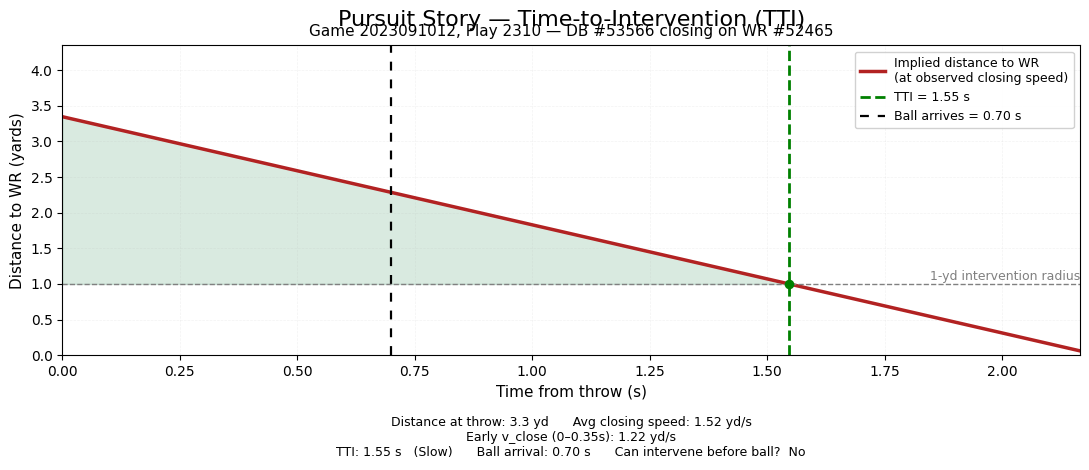

In [26]:
# tti_visual_real.py
#
# Plot a single-play TTI figure using your REAL data:
# - /content/per_play_defender_movement.parquet
# - /content/aggregated_week01.parquet
#
# Each time you run it, it will randomly pick a valid play/defender.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 1. Load data
# -----------------------------
df_tti = pd.read_parquet("/content/per_play_defender_movement.parquet")
df_sg  = pd.read_parquet("/content/aggregated_week01.parquet")

# For a clean merge: aggregated_week01.nfl_id is the WR on that play
df_sg_renamed = df_sg.rename(columns={"nfl_id": "wr_id"})

# Merge on game_id, play_id, wr_id so we can get time_to_land_loc
df_merged = pd.merge(
    df_tti,
    df_sg_renamed[["game_id", "play_id", "wr_id", "time_to_land_loc"]],
    on=["game_id", "play_id", "wr_id"],
    how="inner"
)

# Keep only rows where we have everything we need
mask_valid = (
    df_merged["tti"].notna()
    & df_merged["distance_throw"].notna()
    & df_merged["avg_v_close"].notna()
    & df_merged["time_to_land_loc"].notna()
)

df_valid = df_merged[mask_valid].copy()

if df_valid.empty:
    raise ValueError("No valid rows with non-null tti, distance_throw, avg_v_close, and time_to_land_loc.")

# -----------------------------
# 2. Pick a random play/defender row
# -----------------------------
row = df_valid.sample(1).iloc[0]

game_id       = int(row["game_id"])
play_id       = int(row["play_id"])
defender_id   = int(row["defender_id"])
wr_id         = int(row["wr_id"])
distance_throw = float(row["distance_throw"])
avg_v_close    = float(row["avg_v_close"])
tti            = float(row["tti"])
ball_arrival   = float(row["time_to_land_loc"])
early_v_close  = row.get("early_v_close", np.nan)

db_label = f"DB #{defender_id}"
wr_label = f"WR #{wr_id}"

# -----------------------------
# 3. Build implied distance curve
# -----------------------------
# Set plot window a bit wider than the relevant times
t_max = max(ball_arrival, tti) * 1.4
t_max = max(t_max, 2.0)  # minimum 2 seconds so the plot doesn't get too cramped

t = np.linspace(0, t_max, 300)
dist = np.maximum(distance_throw - avg_v_close * t, 0.0)

# -----------------------------
# 4. Figure & layout
# -----------------------------
fig = plt.figure(figsize=(11, 4.8))

# Use a GridSpec: top = main plot, bottom = summary text
gs = fig.add_gridspec(4, 1, height_ratios=[4, 0.1, 0.1, 1])
ax = fig.add_subplot(gs[0:3, 0])
text_ax = fig.add_subplot(gs[3, 0])
text_ax.axis("off")

# -----------------------------
# 5. Main TTI plot
# -----------------------------
# Implied distance line
ax.plot(
    t, dist,
    color="#b22222", linewidth=2.5,
    label="Implied distance to WR\n(at observed closing speed)"
)

# Shade pursuit area up to TTI (if TTI within window)
if tti <= t_max:
    mask_tti = t <= tti
    ax.fill_between(
        t[mask_tti], dist[mask_tti], 1.0,
        color="#2e8b57", alpha=0.18
    )

# 1-yd intervention radius
ax.axhline(
    1.0, color="gray", linestyle="--", linewidth=1
)
ax.text(
    t_max, 1.02, "1-yd intervention radius",
    ha="right", va="bottom", fontsize=9, color="gray"
)

# Vertical line at TTI (if within window)
if tti <= t_max:
    ax.axvline(
        tti, color="green", linestyle="--", linewidth=2,
        label=f"TTI = {tti:.2f} s"
    )
    ax.scatter(
        [tti], [np.interp(tti, t, dist)],
        color="green", s=35, zorder=5
    )

# Vertical line at ball arrival (if within window)
if ball_arrival <= t_max:
    ax.axvline(
        ball_arrival, color="black",
        linestyle=(0, (4, 4)), linewidth=1.6,
        label=f"Ball arrives = {ball_arrival:.2f} s"
    )

# Axes labels & limits
ax.set_xlabel("Time from throw (s)", fontsize=11)
ax.set_ylabel("Distance to WR (yards)", fontsize=11)
ax.set_xlim(0, t_max)
ax.set_ylim(0, distance_throw + 1)

# Title & subtitle
ax.set_title(
    "Pursuit Story — Time-to-Intervention (TTI)",
    fontsize=16, pad=14
)
subtitle = f"Game {game_id}, Play {play_id} — {db_label} closing on {wr_label}"
ax.text(
    0.5, 1.02, subtitle,
    transform=ax.transAxes,
    ha="center", va="bottom", fontsize=11
)

# Legend
ax.legend(
    loc="upper right",
    fontsize=9,
    frameon=True,
    framealpha=0.9
)

ax.grid(alpha=0.15, linestyle="--", linewidth=0.5)

# -----------------------------
# 6. Summary text BELOW the plot
# -----------------------------
can_intervene = "Yes" if tti < ball_arrival else "No"

# Simple speed rating (you can tune thresholds)
if tti < 1.0:
    tti_label = "Fast"
elif tti < 1.5:
    tti_label = "Moderate"
else:
    tti_label = "Slow"

summary_lines = [
    f"Distance at throw: {distance_throw:.1f} yd      "
    f"Avg closing speed: {avg_v_close:.2f} yd/s",
    f"Early v_close (0–0.35s): "
    + (f"{early_v_close:.2f} yd/s" if not np.isnan(early_v_close) else "N/A"),
    f"TTI: {tti:.2f} s   ({tti_label})      "
    f"Ball arrival: {ball_arrival:.2f} s      "
    f"Can intervene before ball?  {can_intervene}"
]

summary_text = "\n".join(summary_lines)

text_ax.text(
    0.5, 0.5, summary_text,
    ha="center", va="center",
    fontsize=9
)

plt.tight_layout()
plt.show()


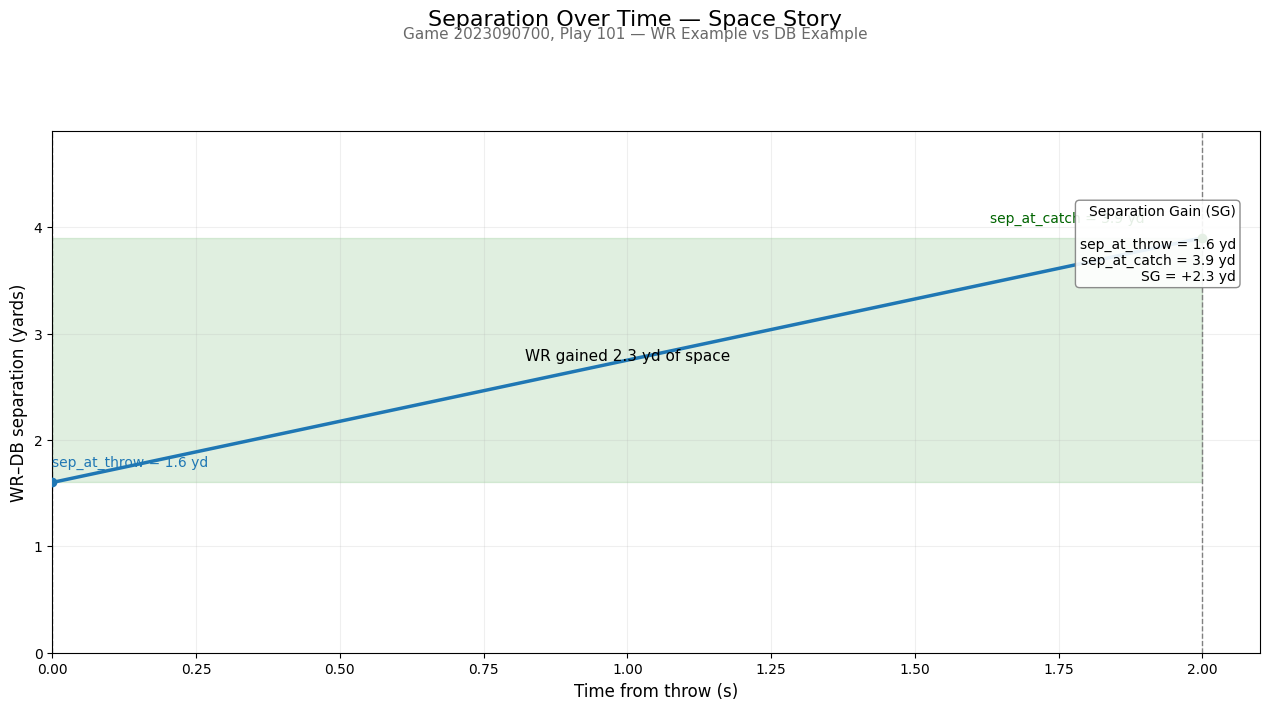

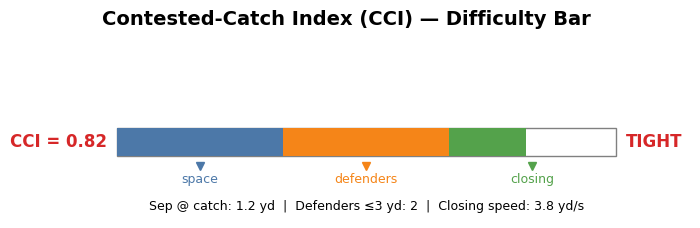

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Dummy Play Data (one play)
# -----------------------------
time_to_land = 2.0  # seconds
time = np.linspace(0, time_to_land, 20)

sep_at_throw = 1.6
sep_at_catch = 3.9
sep_gain = sep_at_catch - sep_at_throw

# Implied smooth separation curve
separation = np.linspace(sep_at_throw, sep_at_catch, len(time))

# Metadata
game_id = 2023090700
play_id = 101
wr_name = "WR Example"
db_name = "DB Example"

# -----------------------------
# Create Figure
# -----------------------------
fig, ax = plt.subplots(figsize=(12.8, 7.2))

# Separation curve
ax.plot(time, separation, color="#1f77b4", linewidth=2.5)

# Throw & Catch markers
ax.axvline(0, linestyle="--", color="gray", linewidth=1)
ax.axvline(time_to_land, linestyle="--", color="gray", linewidth=1)

ax.scatter([0], [sep_at_throw], color="#1f77b4", zorder=3)
ax.scatter(
    [time_to_land],
    [sep_at_catch],
    color="darkgreen" if sep_gain > 0 else "darkred",
    zorder=3
)

# Shaded SG region
ax.fill_between(
    time,
    sep_at_throw,
    sep_at_catch,
    color="green" if sep_gain > 0 else "red",
    alpha=0.12
)

# Axes labels
ax.set_xlabel("Time from throw (s)", fontsize=12)
ax.set_ylabel("WR–DB separation (yards)", fontsize=12)

# Axis limits
ax.set_xlim(0, time_to_land + 0.1)
ax.set_ylim(0, max(sep_at_throw, sep_at_catch) + 1)

# Grid
ax.grid(True, alpha=0.2)

# -----------------------------
# Annotations
# -----------------------------
ax.text(0, sep_at_throw + 0.15, f"sep_at_throw = {sep_at_throw:.1f} yd",
        fontsize=10, color="#1f77b4")

ax.text(time_to_land - 0.1, sep_at_catch + 0.15,
        f"sep_at_catch = {sep_at_catch:.1f} yd",
        fontsize=10, ha="right", color="darkgreen")

ax.text(time_to_land / 2, (sep_at_throw + sep_at_catch) / 2,
        f"WR gained {sep_gain:.1f} yd of space",
        fontsize=11, ha="center")

# SG summary box
sg_text = (
    "Separation Gain (SG)\n\n"
    f"sep_at_throw = {sep_at_throw:.1f} yd\n"
    f"sep_at_catch = {sep_at_catch:.1f} yd\n"
    f"SG = {sep_gain:+.1f} yd"
)
ax.text(
    0.98, 0.86,
    sg_text,
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=10,
    bbox=dict(
        boxstyle="round",
        facecolor="white",
        edgecolor="gray",
        alpha=0.9
    )
)

# -----------------------------
# Title & Subtitle (no overlap)
# -----------------------------
fig.suptitle(
    "Separation Over Time — Space Story",
    fontsize=16,
    y=0.98
)

fig.text(
    0.5, 0.94,
    f"Game {game_id}, Play {play_id} — {wr_name} vs {db_name}",
    ha="center",
    fontsize=11,
    color="dimgray"
)

# Layout control
plt.tight_layout(rect=[0, 0, 1, 0.88])

# -----------------------------
# Show / Save
# -----------------------------
plt.show()
# plt.savefig("figure_sg_space_story.png", dpi=150, bbox_inches="tight")
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# -----------------------------
# Dummy CCI play inputs
# -----------------------------
cci = 0.82                      # overall CCI (0–1)
sep_at_catch = 1.2              # yards
defenders_within_3 = 2
closing_speed = 3.8             # yd/s

# Category thresholds (you can tweak)
if cci < 0.40:
    cat_label = "OPEN"
    cat_color = "#2ca02c"      # green
elif cci < 0.75:
    cat_label = "MODERATE"
    cat_color = "#ff7f0e"      # amber
else:
    cat_label = "TIGHT"
    cat_color = "#d62728"      # red

# -----------------------------
# Figure + axis
# -----------------------------
fig, ax = plt.subplots(figsize=(7.2, 2.4))
fig.suptitle("Contested-Catch Index (CCI) — Difficulty Bar",
             fontsize=14, fontweight="bold", y=0.93)

ax.set_xlim(-0.15, 1.15)
ax.set_ylim(0.0, 1.0)
ax.axis("off")  # hide axes

# -----------------------------
# Segment definition (space / defenders / closing)
# -----------------------------
segments = [
    ("space",     0.00, 1/3,  "#4C78A8"),  # blue
    ("defenders", 1/3,  2/3,  "#F58518"),  # orange
    ("closing",   2/3,  1.00, "#54A24B")   # green
]

bar_y = 0.5       # vertical center of bar
bar_h = 0.18      # bar height

# Outer bar outline (full 0–1 range)
outer = Rectangle((0, bar_y - bar_h/2),
                  1.0, bar_h,
                  linewidth=1.0,
                  edgecolor="gray",
                  facecolor="none")
ax.add_patch(outer)

# Fill each component segment up to CCI
for label, x0, x1, color in segments:
    # how far into this segment does CCI reach?
    fill_end = min(cci, x1)
    if fill_end > x0:  # only draw if CCI passes the start of this segment
        width = fill_end - x0
        seg_rect = Rectangle((x0, bar_y - bar_h/2),
                             width, bar_h,
                             linewidth=0,
                             facecolor=color)
        ax.add_patch(seg_rect)

# -----------------------------
# Left "CCI =" label
# -----------------------------
ax.text(-0.02, bar_y,
        f"CCI = {cci:.2f}",
        ha="right", va="center",
        fontsize=12, fontweight="bold",
        color=cat_color)

# -----------------------------
# Right category label
# -----------------------------
ax.text(1.02, bar_y,
        cat_label,
        ha="left", va="center",
        fontsize=12, fontweight="bold",
        color=cat_color)

# -----------------------------
# Component markers under bar
# -----------------------------
marker_y = bar_y - bar_h/2 - 0.07
label_y  = marker_y - 0.04

for label, x0, x1, color in segments:
    xpos = (x0 + x1) / 2
    # small triangle marker
    ax.plot(xpos, marker_y, marker='v', markersize=6,
            color=color, clip_on=False)
    # text label
    ax.text(xpos, label_y, label,
            ha="center", va="top",
            fontsize=9, color=color)

# -----------------------------
# Footer line with context
# -----------------------------
footer_text = (
    f"Sep @ catch: {sep_at_catch:.1f} yd  |  "
    f"Defenders ≤3 yd: {defenders_within_3}  |  "
    f"Closing speed: {closing_speed:.1f} yd/s"
)

ax.text(0.5, 0.08,
        footer_text,
        ha="center", va="center",
        fontsize=9, color="black")

plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()


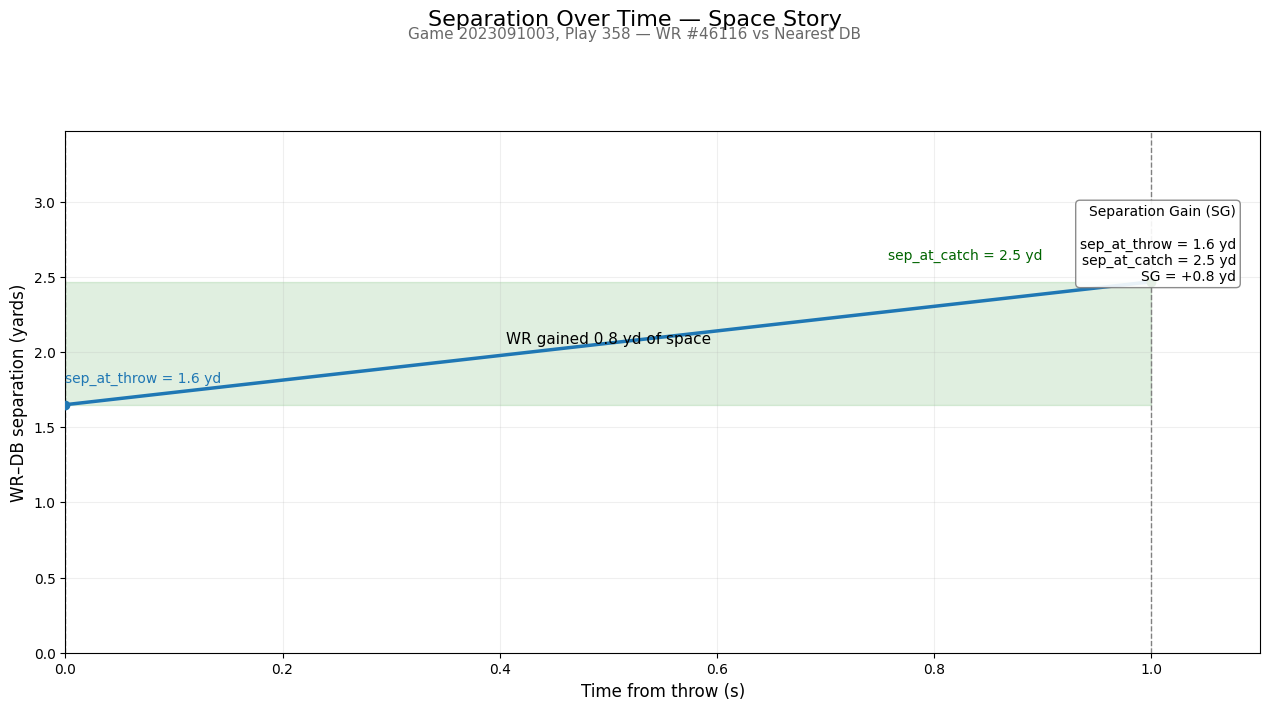

Plotted SG for Game 2023091003, Play 358, WR nfl_id=46116


In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 1. Load SG data & pick a complete play
# -----------------------------
SG_PATH = "/content/aggregated_week01.parquet"

df_sg = pd.read_parquet(SG_PATH)

# Keep only rows where SG is defined
mask = (
    df_sg["sep_at_throw"].notna() &
    df_sg["sep_at_catch_end"].notna() &
    df_sg["sep_gain"].notna() &
    df_sg["time_to_land_loc"].notna()
)

df_valid = df_sg[mask].copy()

if df_valid.empty:
    raise ValueError("No valid SG rows found (check sep_* and time_to_land_loc).")

# Pick a random complete play each run
row = df_valid.sample(1).iloc[0]

game_id = int(row["game_id"])
play_id = int(row["play_id"])
nfl_id = int(row["nfl_id"])

sep_at_throw = float(row["sep_at_throw"])
sep_at_catch = float(row["sep_at_catch_end"])
sep_gain = float(row["sep_gain"])
time_to_land = float(row["time_to_land_loc"])

# Optional label (you can join to a roster later if you want real names)
wr_name = f"WR #{nfl_id}"
db_name = "Nearest DB"

# -----------------------------
# 2. Build implied separation curve
# -----------------------------
# Time axis from throw (0) to ball arrival
num_points = 20
time = np.linspace(0.0, time_to_land, num_points)

# Smooth straight-line separation from throw -> catch
separation = np.linspace(sep_at_throw, sep_at_catch, num_points)

# -----------------------------
# 3. Create Figure
# -----------------------------
fig, ax = plt.subplots(figsize=(12.8, 7.2))

# Separation curve
ax.plot(time, separation, color="#1f77b4", linewidth=2.5)

# Throw & Catch markers
ax.axvline(0, linestyle="--", color="gray", linewidth=1)
ax.axvline(time_to_land, linestyle="--", color="gray", linewidth=1)

ax.scatter([0], [sep_at_throw], color="#1f77b4", zorder=3)
ax.scatter(
    [time_to_land],
    [sep_at_catch],
    color="darkgreen" if sep_gain > 0 else "darkred",
    zorder=3
)

# Shaded SG region
ax.fill_between(
    time,
    sep_at_throw,
    sep_at_catch,
    color="green" if sep_gain > 0 else "red",
    alpha=0.12
)

# Axes labels
ax.set_xlabel("Time from throw (s)", fontsize=12)
ax.set_ylabel("WR–DB separation (yards)", fontsize=12)

# Axis limits
ax.set_xlim(0, time_to_land + 0.1)
ax.set_ylim(
    0,
    max(sep_at_throw, sep_at_catch) + 1
)

# Grid
ax.grid(True, alpha=0.2)

# -----------------------------
# 4. Annotations
# -----------------------------
ax.text(
    0, sep_at_throw + 0.15,
    f"sep_at_throw = {sep_at_throw:.1f} yd",
    fontsize=10, color="#1f77b4"
)

ax.text(
    time_to_land - 0.1, sep_at_catch + 0.15,
    f"sep_at_catch = {sep_at_catch:.1f} yd",
    fontsize=10, ha="right",
    color="darkgreen" if sep_gain > 0 else "darkred"
)

center_y = (sep_at_throw + sep_at_catch) / 2
ax.text(
    time_to_land / 2, center_y,
    (
        f"WR gained {sep_gain:.1f} yd of space"
        if sep_gain > 0
        else f"WR lost {abs(sep_gain):.1f} yd of space"
    ),
    fontsize=11, ha="center"
)

# SG summary box
sg_text = (
    "Separation Gain (SG)\n\n"
    f"sep_at_throw = {sep_at_throw:.1f} yd\n"
    f"sep_at_catch = {sep_at_catch:.1f} yd\n"
    f"SG = {sep_gain:+.1f} yd"
)
ax.text(
    0.98, 0.86,
    sg_text,
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=10,
    bbox=dict(
        boxstyle="round",
        facecolor="white",
        edgecolor="gray",
        alpha=0.9
    )
)

# -----------------------------
# 5. Title & Subtitle (no overlap)
# -----------------------------
fig.suptitle(
    "Separation Over Time — Space Story",
    fontsize=16,
    y=0.98
)

fig.text(
    0.5, 0.94,
    f"Game {game_id}, Play {play_id} — {wr_name} vs {db_name}",
    ha="center",
    fontsize=11,
    color="dimgray"
)

# Layout control
plt.tight_layout(rect=[0, 0, 1, 0.88])

# -----------------------------
# 6. Show / Save
# -----------------------------
plt.show()
# plt.savefig("figure_sg_space_story_realdata.png", dpi=150, bbox_inches="tight")

print(f"Plotted SG for Game {game_id}, Play {play_id}, WR nfl_id={nfl_id}")


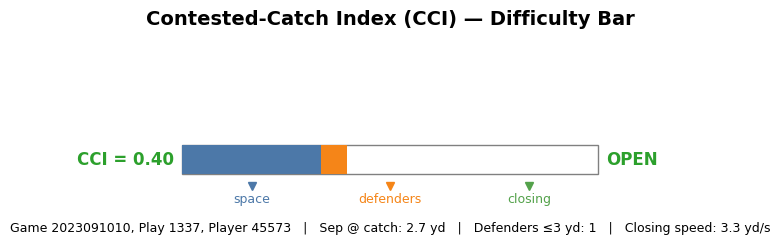

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np

# -----------------------------
# 1. Load CCI dataset
# -----------------------------
cci_path = "/content/metric_cci.parquet"
df_cci = pd.read_parquet(cci_path)

# Keep only rows where CCI + core ingredients are available
valid = df_cci.dropna(subset=["CCI", "sep_at_catch", "defenders_within_3yd", "closing_speed_at_catch"])
if valid.empty:
    raise ValueError("No rows with non-null CCI, sep_at_catch, defenders_within_3yd, and closing_speed_at_catch found.")

# Randomly pick one play each run
row = valid.sample(1).iloc[0]

game_id = int(row["game_id"])
play_id = int(row["play_id"])
nfl_id = int(row["nfl_id"])

cci = float(row["CCI"])
sep_at_catch = float(row["sep_at_catch"])
defenders_within_3 = int(row["defenders_within_3yd"])
closing_speed = float(row["closing_speed_at_catch"])

# -----------------------------
# 2. Decide category & color
#    Prefer dataset's CCI_category if present
# -----------------------------
cat_from_data = None
if "CCI_category" in row.index and pd.notna(row["CCI_category"]):
    cat_from_data = str(row["CCI_category"]).upper()

if cat_from_data in {"OPEN", "MODERATE", "TIGHT"}:
    cat_label = cat_from_data
else:
    # Fallback: derive from thresholds
    if cci < 0.40:
        cat_label = "OPEN"
    elif cci < 0.75:
        cat_label = "MODERATE"
    else:
        cat_label = "TIGHT"

# Color mapping by category
cat_color_map = {
    "OPEN": "#2ca02c",      # green
    "MODERATE": "#ff7f0e",  # amber
    "TIGHT": "#d62728"      # red
}
cat_color = cat_color_map.get(cat_label, "#d62728")

# -----------------------------
# 3. Figure + axis
# -----------------------------
fig, ax = plt.subplots(figsize=(7.5, 2.6))
fig.suptitle(
    "Contested-Catch Index (CCI) — Difficulty Bar",
    fontsize=14, fontweight="bold", y=0.95
)

ax.set_xlim(-0.15, 1.15)
ax.set_ylim(0.0, 1.0)
ax.axis("off")  # hide axes

# -----------------------------
# 4. Segment definition (space / defenders / closing)
# -----------------------------
segments = [
    ("space",     0.00, 1/3,  "#4C78A8"),  # blue
    ("defenders", 1/3,  2/3,  "#F58518"),  # orange
    ("closing",   2/3,  1.00, "#54A24B")   # green
]

bar_y = 0.5       # vertical center of bar
bar_h = 0.18      # bar height

# Outer bar outline (full 0–1 range)
outer = Rectangle(
    (0, bar_y - bar_h/2),
    1.0, bar_h,
    linewidth=1.0,
    edgecolor="gray",
    facecolor="none"
)
ax.add_patch(outer)

# Fill each component segment up to CCI
for label, x0, x1, color in segments:
    # how far into this segment does CCI reach?
    fill_end = min(cci, x1)
    if fill_end > x0:  # only draw if CCI passes the start of this segment
        width = fill_end - x0
        seg_rect = Rectangle(
            (x0, bar_y - bar_h/2),
            width, bar_h,
            linewidth=0,
            facecolor=color
        )
        ax.add_patch(seg_rect)

# -----------------------------
# 5. Left "CCI =" label
# -----------------------------
ax.text(
    -0.02, bar_y,
    f"CCI = {cci:.2f}",
    ha="right", va="center",
    fontsize=12, fontweight="bold",
    color=cat_color
)

# -----------------------------
# 6. Right category label
# -----------------------------
ax.text(
    1.02, bar_y,
    cat_label,
    ha="left", va="center",
    fontsize=12, fontweight="bold",
    color=cat_color
)

# -----------------------------
# 7. Component markers under bar
# -----------------------------
marker_y = bar_y - bar_h/2 - 0.07
label_y  = marker_y - 0.04

for label, x0, x1, color in segments:
    xpos = (x0 + x1) / 2
    # small triangle marker
    ax.plot(
        xpos, marker_y,
        marker="v", markersize=6,
        color=color, clip_on=False
    )
    # text label
    ax.text(
        xpos, label_y, label,
        ha="center", va="top",
        fontsize=9, color=color
    )

# -----------------------------
# 8. Footer line with context
# -----------------------------
footer_text = (
    f"Game {game_id}, Play {play_id}, Player {nfl_id}   |   "
    f"Sep @ catch: {sep_at_catch:.1f} yd   |   "
    f"Defenders ≤3 yd: {defenders_within_3}   |   "
    f"Closing speed: {closing_speed:.1f} yd/s"
)

ax.text(
    0.5, 0.08,
    footer_text,
    ha="center", va="center",
    fontsize=9, color="black"
)

plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.show()
